In [2]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_TTX
from nrem_analysis.utils import plot_intervals

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import cmap

import scipy.ndimage
import seaborn as sns

cyclic_cmap = cmap.Colormap('cmocean:phase').to_mpl()

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 320,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

up_color = "#D55E00"
threshold_color = "#C44E52"

def detect_upstates(
    spikes: nap.TsGroup,
    bin_size = 0.01,
    percentile = 80,
    merge_thr = 0.1,
    short_thr = 0.04,
    long_thr = 2,
    time_units='s'
    ) -> nap.IntervalSet:
    x = spikes.count(bin_size=bin_size, time_units=time_units).sum(axis=1)
    x = x / bin_size
    x = x.smooth(std=2 * bin_size, time_units=time_units)
    thr = np.percentile(x, q=percentile)

    up_states = x.threshold(thr, method='above').time_support
    up_states = up_states.merge_close_intervals(threshold=merge_thr, time_units=time_units)
    up_states = up_states.drop_short_intervals(threshold=short_thr, time_units=time_units)
    up_states = up_states.drop_long_intervals(threshold=long_thr, time_units=time_units)
    return up_states, thr

In [3]:
mouse_id        = "116b"
data_dir        = INTERIM_DIR / mouse_id

sleep           = nap.load_file(PROCESSED_DIR / "ttx" / mouse_id / "sleep.npz")
hd_units        = nap.load_file(PROCESSED_DIR / "ttx" / mouse_id / "hd_units.npz")
virtual_hds     = nap.load_file(PROCESSED_DIR / "ttx" / mouse_id / "virtual_hd.npz")
virtual_states  = nap.load_file(PROCESSED_DIR / "ttx" / mouse_id / "virtual_states.npz")
session         = nap.load_file(PROCESSED_DIR / "ttx" / mouse_id / "sessions.npz")

nrem = sleep[sleep['state'] == 'nrem'].intersect(session[session['label'] == 'homecage'])
cont_eps = virtual_states['continuous'].threshold(0.5).time_support
pref_angle = np.rad2deg(hd_units['head_direction'].to_numpy())

# order unit ids
order = np.argsort(pref_angle)
hd_uids = np.array(hd_units.keys())[order]

# detect up states
spikes = hd_units.restrict(nrem)
up_states, thr = detect_upstates(spikes)

# valid eps
valid_eps = up_states.intersect(cont_eps)

(<Figure size 2100x375 with 1 Axes>, <Axes: xlabel='Time (s)'>)

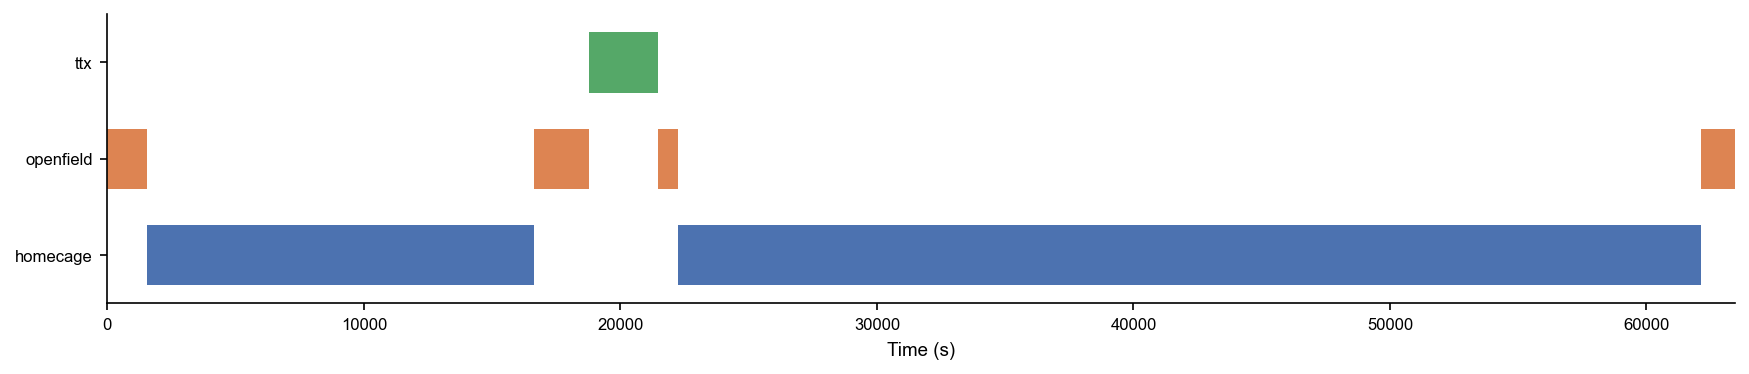

In [3]:
plot_intervals(session, column='label')

<Axes: ylabel='Count'>

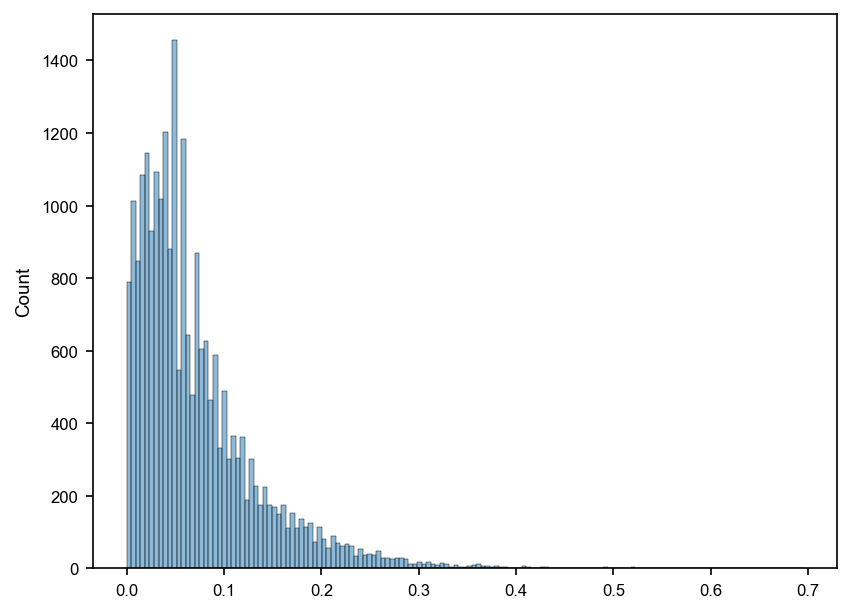

In [4]:
sns.histplot(np.diff(valid_eps.values), legend=False)

In [5]:
ep = nrem[51]
print(ep)

hd_spikes = hd_units.restrict(ep)
up_eps = up_states.intersect(ep)
c_eps = cont_eps.intersect(ep)
v_eps = valid_eps.intersect(ep)
vhd = virtual_hds.restrict(ep)

# HD units population vector
hd_pv = hd_spikes.count(bin_size=0.01).sum(axis=1) / 0.01 
hd_pv = hd_pv.smooth(std=0.02)

  index    start    end  state    label
      0    28537  28716  nrem     homecage
shape: (1, 2), time unit: sec.


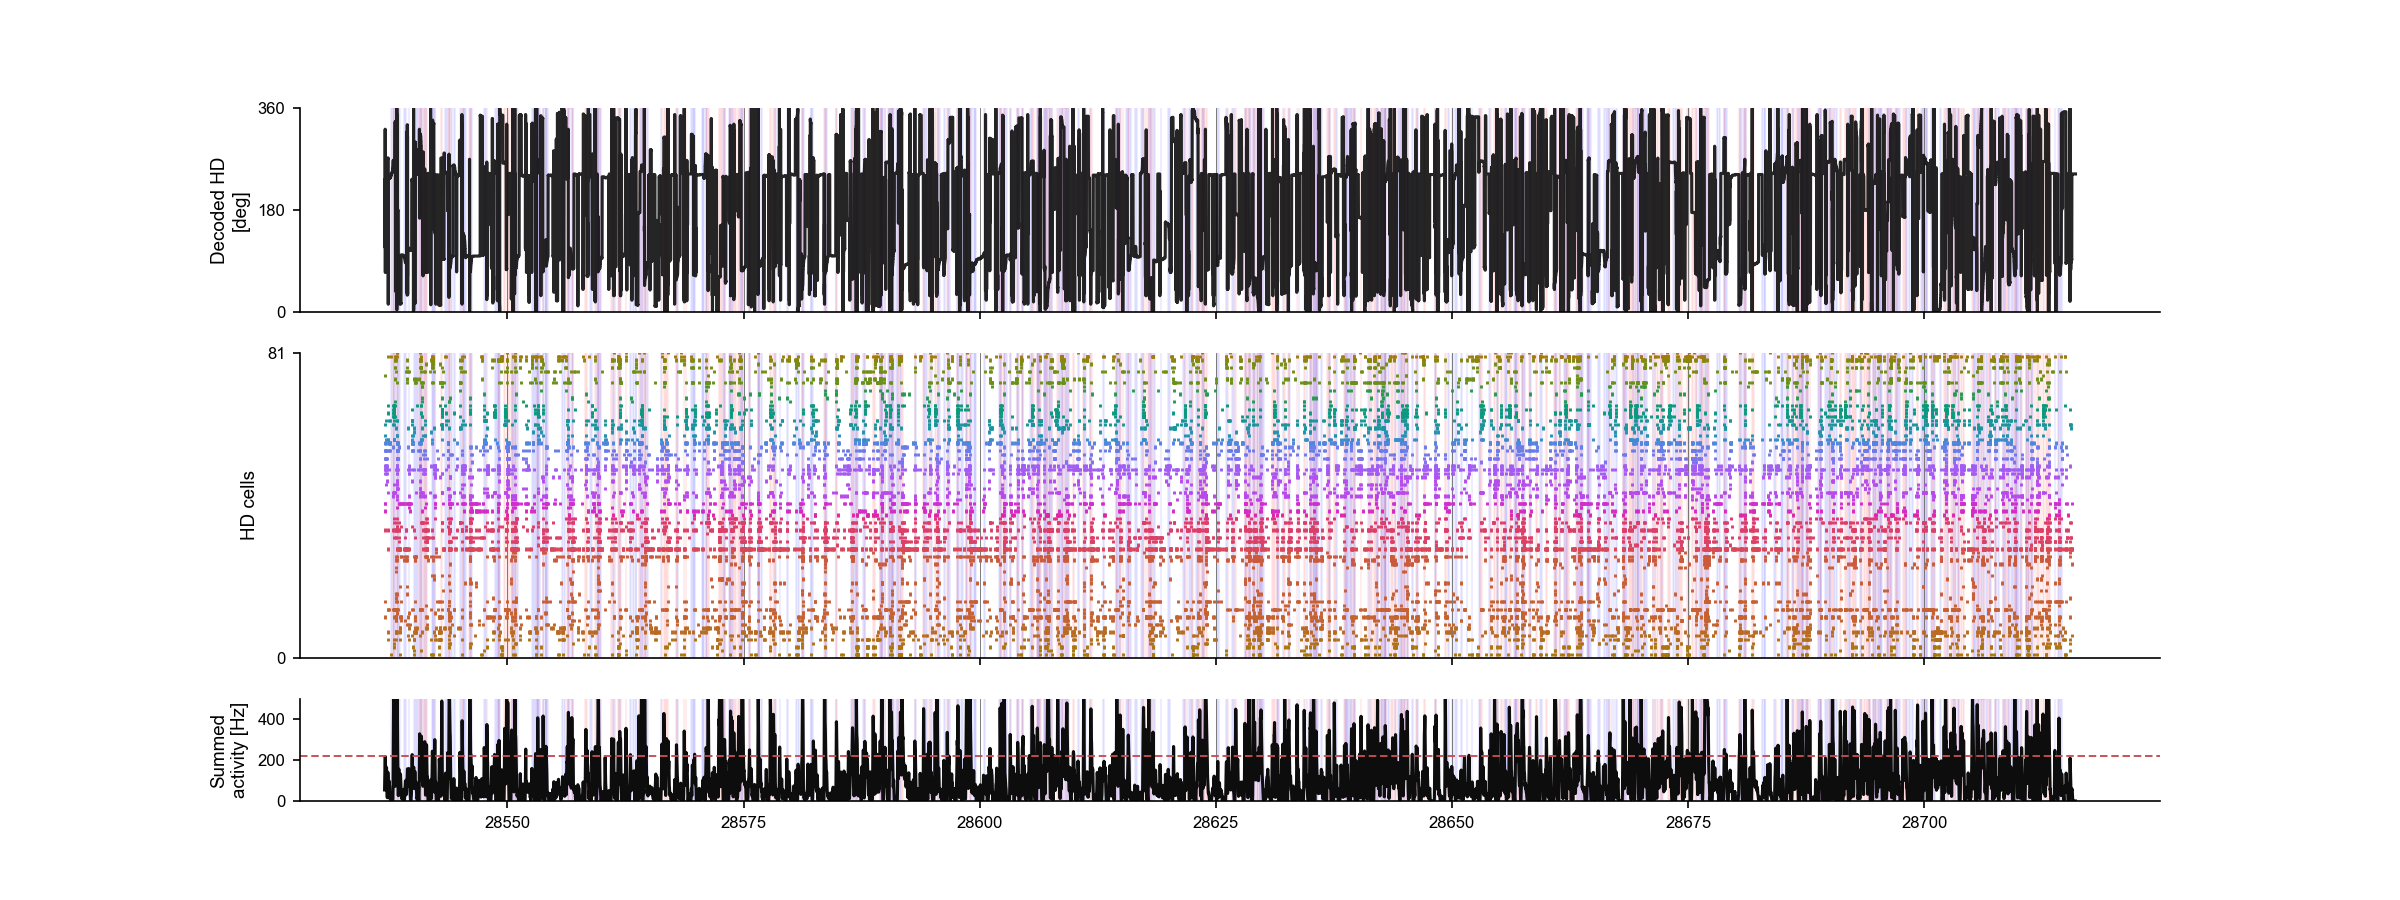

In [6]:
%matplotlib ipympl
f, ax = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 3, 1]})

# Decoded HD
ax[0].plot(vhd, color='0.05', alpha=0.9, linewidth=1.5)
# for ep in valid_eps:
#     ax[0].plot(vhd.restrict(ep), color='0.05', alpha=0.9, linewidth=1.5)

# Up states
for a in ax[:3]:
    for eps, color in zip((up_eps, c_eps), ('red', 'blue')):
        for start, end in eps.values:
            a.axvspan(
                start, end,
                color=color,
                alpha=0.07,
                zorder=0,
                )

# HD cells raster
for row, uid in enumerate(hd_uids, start=1):
    ax[1].eventplot(
        hd_spikes[uid].index,
        lineoffsets=row,
        linelengths=0.9,
        linewidths=1.4,
        colors=[cyclic_cmap(pref_angle[uid].item() / 360)],
        alpha=1,
    )

# HD cells population
ax[2].plot(hd_pv, linewidth=1.5, color='0.05')
ax[2].axhline(
    thr,
    color=threshold_color,
    linestyle=(0, (4, 2)),
    linewidth=0.9,
    )

for a in ax:
    a.set_axisbelow(True)
    a.grid(axis='x', which='major', color='0.4', linewidth=0.4)
    a.spines[["top", "right"]].set_visible(False)

ax[0].set_ylabel("Decoded HD\n[deg]")
ax[0].set_ylim((0, 360))
ax[0].set_yticks([0, 180, 360])

ax[1].set_ylabel("HD cells")
ax[1].set_ylim(0, len(hd_uids))
ax[1].set_yticks([0, len(hd_uids)])

ax[2].set_ylabel("Summed\nactivity [Hz]")
# ax[2].set_yticks([0, 200, 400])
ax[2].set_ylim((0, 500))

# plt.savefig(FIGURES_DIR / "snapshots" / "nrem_upstates01.svg", format='svg', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "snapshots" / "nrem_upstates01.png", format='png', bbox_inches='tight')
plt.show()